<a href="https://colab.research.google.com/github/Rahii2001/computational-data-analysis/blob/main/Deliverable_1_Birmingham_Heat_Risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deliverable 1 — Heat-Risk Screening (Birmingham)

**Course:** Computational Data Analysis with Python
**Project track:** Track 1: *Heat-risk screening* ("Which locations are most at risk of high heat exposure?")  
**City for this deliverable:** Birmingham (UK), Probably will be extended to 2 more cities.  
**Group:** Raheel Ahmed  


---

## Notebook outline

1. Problem framing: question, target, intended use, success criteria
2. Data description: source, scope, variables
3. Loading the data: SEF parser + station metadata join
4. Data understanding: variables, time coverage, sample rows
5. Data quality checks: missingness, duplicates, time gaps, sentinel values
6. Initial exploratory data analysis
7. Initial heat-risk metric and station ranking
8. Conclusions and plan for Deliverable 2

## 1. Problem framing

### 1.1 Question
**Within the city of Birmingham, which monitoring locations are most exposed to high air temperatures, and how should public-health and urban-planning authorities prioritize heat-mitigation interventions across the city?**


### 1.3 Target / outcome of interest
A **per-station heat-risk score** that summarises how much hot-temperature exposure occurred at each location over the observation period. We use station-level scores to produce a **ranking** of locations from highest to lowest heat-risk; the ranking is the operational deliverable.

### 1.6 Key assumptions

- Each station is treated as a proxy for its surrounding neighbourhood (no population weighting at this stage).
- Sensor placement and exposure are comparable across stations: all 23 sites use the same sensor type (Aginova Sentinel Micro / Vaisala WXT) at 2–3 m above ground, all operated by the same network (University of Birmingham Urban Climate Lab). This is a strong reason to choose Birmingham for the first deliverable, it removes a major source of cross-station inhomogeneity that affects denser networks like Basel or Zurich.
- The study window (October 2019 to August 2022) is short enough that long-term climate trend is not the dominant signal; spatial differences within the city are.
- Temperature alone proxies for heat exposure; we ignore humidity (heat index), radiation, and wind in this initial screening.

In [ ]:
import kagglehub
path = kagglehub.dataset_download("pablomoratodomnguez/fairurbtemp-curated")

Using Colab cache for faster access to the 'fairurbtemp-curated' dataset.


## 2. Data description

**Source:** [FAIRUrbTemp dataset](https://doi.org/10.6084/m9.figshare.29994877)

**Full dataset:** 811 sensors across 12 European cities. Hourly aggregate temperature in Station Exchange Format (SEF v1.0.0).

**Birmingham subset used here:**

- 23 street-level temperature stations.
- Hourly mean air temperature in °C.
- Window: 2019-10-28 to 2022-08-26 (~2.8 years of data).
- Geographic span: latitude 52.37 to 52.57, longitude −2.06 to −1.79 (≈22 km N–S × 19 km E–W).
- Pre-applied QC flags: gross_errors, out_of_range, time_consistency, temporal_persistance, climatic_outliers, spatiotemporal_consistency, spatial_consistency.

## 3. Loading the data

In [18]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.titlesize': 11, 'axes.labelsize': 10})

# Based on kernel state, files are in /content/
DATA_ROOT = Path('/content')
HOURLY_DIR = DATA_ROOT
META_DIR   = DATA_ROOT

### 3.1 SEF parser

Each FAIRUrbTemp file is in the [Station Exchange Format (SEF) v1.0.0](https://datarescue.climate.copernicus.eu/node/80), a 12-line plain-text header followed by a tab-separated data block. Here i write a small parser to extract both the header (station metadata) and the time series.

In [19]:
SEF_HEADER_KEYS = {"SEF", "ID", "Name", "Lat", "Lon", "Alt",
                   "Source", "Link", "Vbl", "Stat", "Units", "Meta"}

def parse_sef_file(path: Path):
    """Parse a single SEF v1.0.0 TSV file. Returns (header_dict, dataframe)."""
    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    header, data_start = {}, 0
    for i, line in enumerate(lines):
        parts = line.rstrip("\n").split("\t")
        if parts and parts[0] in SEF_HEADER_KEYS and len(parts) >= 2:
            header[parts[0]] = parts[1]
        elif parts and parts[0] == "Year":
            data_start = i + 1
            break

    rows = []
    for line in lines[data_start:]:
        parts = line.rstrip("\n").split("\t")
        if len(parts) < 7:
            continue
        try:
            y, m, d, hh, mm = (int(parts[0]), int(parts[1]),
                               int(parts[2]), int(parts[3]),
                               int(parts[4]))
        except ValueError:
            continue
        v = parts[6].strip()
        value = float(v) if v not in ("", "NA", "NaN") else np.nan
        flag = parts[7].strip() if len(parts) > 7 else ""
        rows.append((y, m, d, hh, mm, value, flag))

    df = pd.DataFrame(rows, columns=["year","month","day","hour","minute","ta_C","qc_flag"])
    df["timestamp"] = pd.to_datetime(df[["year","month","day","hour","minute"]],
                                     errors="coerce", utc=True)
    return header, df[["timestamp", "ta_C", "qc_flag"]]


def load_city(hourly_dir: Path):
    long_frames, header_records = [], []
    for fp in sorted(hourly_dir.glob("*.tsv")):
        header, df = parse_sef_file(fp)
        station_id = fp.stem.replace("_AirTemp_hourly_UTC", "").replace("_AirTemp_Hourly_UTC", "")
        df["station_id"] = station_id
        long_frames.append(df)
        header_records.append({"station_id": station_id, **header})
    return (pd.concat(long_frames, ignore_index=True),
            pd.DataFrame(header_records))

In [20]:
# Re-running the load with the corrected DATA_ROOT
df, headers = load_city(HOURLY_DIR)
station_meta = pd.read_csv(META_DIR / 'station_metadata_Birmingham.tsv', sep='\t')
meas_meta    = pd.read_csv(META_DIR / 'measurement_metadata_Birmingham.tsv', sep='\t')
network_meta = pd.read_csv(META_DIR / 'network_metadata_Birmingham.tsv', sep='\t')

print(f'Long-format dataframe: {len(df):,} rows, {df["station_id"].nunique()} stations')
print(f'Date range: {df["timestamp"].min()}  ->  {df["timestamp"].max()}')
df.head()

Long-format dataframe: 570,515 rows, 23 stations
Date range: 2019-10-28 11:00:00+00:00  ->  2022-08-26 23:00:00+00:00


/tmp/ipykernel_5059/2148430461.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return (pd.concat(long_frames, ignore_index=True),


,timestamp,ta_C,qc_flag,station_id
0,2019-10-28 11:00:00+00:00,NaN,,Allens_Croft
1,2019-10-28 12:00:00+00:00,NaN,,Allens_Croft
2,2019-10-28 13:00:00+00:00,NaN,,Allens_Croft
3,2019-10-28 14:00:00+00:00,NaN,,Allens_Croft
4,2019-10-28 15:00:00+00:00,NaN,,Allens_Croft


## 4. Data understanding

**Variables in the long-format dataframe**

**Station metadata** (`station_meta`) provides latitude, longitude, station number, and sensor height (2–3 m for all 23 Birmingham stations). Note that altitude is **not recorded** for Birmingham (the SEF `Alt` field literally reads `"Alt"`).

**Network metadata** confirms a single operator (University of Birmingham), single sensor type, 5-minute raw measurement interval averaged to hourly.

Nine time-derived columns (year, month, hour, date) are created below for grouping in EDA.

In [21]:
df['year']  = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['hour']  = df['timestamp'].dt.hour
df['date']  = df['timestamp'].dt.date

# Display station metadata sample
station_meta.head()

,city,station_id,station_number,latitude,longitude,sensor_height_m
0,Birmingham,Allens_Croft,ENG_BHM_001,52.421122,-1.913435,2-3 m
1,Birmingham,Archbishop_Ilsley,ENG_BHM_002,52.444539,-1.821489,2-3 m
2,Birmingham,Bell_Heath,ENG_BHM_003,52.396292,-2.062205,2-3 m
3,Birmingham,Chilcote,ENG_BHM_004,52.416700,-1.843370,2-3 m
4,Birmingham,Colebourne,ENG_BHM_005,52.492413,-1.807763,2-3 m


## 5. Data quality checks

We run four standard checks before any EDA:

1. Missingness per station,
2. Duplicate (station, timestamp) rows,
3. Time gaps in the hourly grid,
4. Range / sentinel-value check on the temperature values.



### 5.1 Missingness per station

We compute the percentage of hourly rows where `ta_C` is `NaN`. The NA-fraction varies hugely between stations, from 0.2 % to 69.6 %. This will matter when we interpret the heat-risk ranking later: a station with 70 % missing data has a much less reliable score than one with 0 % missing.

In [23]:
miss = (df.assign(missing=df['ta_C'].isna())
          .groupby('station_id')['missing'].mean() * 100).round(2)
miss = miss.sort_values(ascending=False).rename('missing_pct')
miss.to_frame()

,missing_pct
station_id,
Thinktank,69.60
Allens_Croft,53.96
Colebourne,41.87
Donkey_Sanctuary,40.15
Moseley,38.14
Warley_Woods,32.09
Rookery_Road,31.65
Northfield_Manor,31.52
Archbishop_Ilsley,15.32


**Interpretation.** Missingness is highly heterogeneous and clusters into three groups: (a) a *complete-record* group (12 stations with ≤10 % missing), (b) a *moderate gaps* group (6 stations with 10–35 % missing), and (c) a *sparse* group (5 stations with 35–70 % missing). For the ranking step we will mark sparse-coverage stations explicitly so a city official does not act on a metric computed from very few observations.

### 5.2 Duplicates and time gaps

We check that no `(station_id, timestamp)` pair appears twice, and that the hourly grid has no unexpected jumps.

In [24]:
dup_count = int(df.duplicated(subset=['station_id', 'timestamp']).sum())

def gap_summary(g):
    g = g.sort_values('timestamp')
    diffs = g['timestamp'].diff().dropna()
    return pd.Series({'n_unexpected_gaps': int((diffs != pd.Timedelta(hours=1)).sum()),
                      'max_gap_hours': diffs.max().total_seconds() / 3600 if len(diffs) else 0})

gaps = df.groupby('station_id', group_keys=False)[['timestamp']].apply(gap_summary)
print(f'Duplicate (station, timestamp) rows: {dup_count}')
print(f'Stations with no unexpected gaps: {(gaps["n_unexpected_gaps"] == 0).sum()} / {len(gaps)}')
print(f'Max gap across all stations: {gaps["max_gap_hours"].max():.1f} h')

Duplicate (station, timestamp) rows: 0
Stations with no unexpected gaps: 23 / 23
Max gap across all stations: 1.0 h


**Interpretation.** No duplicates and a perfectly regular hourly grid in every station file. Where a measurement is unavailable, the row is preserved with `ta_C = NaN` rather than being dropped — that is why missingness is encoded as `NaN` rather than as a gap.

### 5.3 Range / sentinel-value check

A simple sanity check on the values immediately reveals a problem the provider's QC pipeline did not catch.

In [25]:
val_raw = df['ta_C'].dropna()
print(f'Min: {val_raw.min():.2f} °C   Max: {val_raw.max():.2f} °C')
print(f'Values below -25 °C: {(val_raw < -25).sum()}')
print(f'Values above  45 °C: {(val_raw > 45).sum()}')
print('\nSample of suspect (<-25 °C) values:')
print(df.loc[df['ta_C'] < -25, 'ta_C'].head(10).tolist())

Min: -488.33 °C   Max: 37.52 °C
Values below -25 °C: 584
Values above  45 °C: 0

Sample of suspect (<-25 °C) values:
[-152.97, -147.42, -150.08, -156.06, -157.85, -158.88, -166.6, -159.35, -159.05, -162.23]


**Interpretation.** The minimum recorded temperature is **−488.33 °C**, physically impossible (below absolute zero). Inspecting the 584 sub −25 °C observations shows they cluster around −150 °C with no plausible gradient, strongly suggesting a *sensor failure / disconnect code* (some sensor firmware reports a fixed negative value when communication fails). These values were retained by the data provider's QC and would silently corrupt our metrics if we did not filter them. We apply a physical-plausibility filter: keep only −25 °C ≤ T ≤ +50 °C (Birmingham's all-time station record extremes are roughly −20 °C to +40 °C).

In [26]:
PHYS_MIN, PHYS_MAX = -25.0, 50.0
mask_sentinel = (df['ta_C'] < PHYS_MIN) | (df['ta_C'] > PHYS_MAX)
n_sentinel = int(mask_sentinel.sum())
sentinel_by_station = df[mask_sentinel].groupby('station_id').size().rename('n_sentinel')
df.loc[mask_sentinel, 'ta_C'] = np.nan       # convert to NaN

print(f'Sentinel values removed: {n_sentinel}')
print('Affected stations:')
print(sentinel_by_station.sort_values(ascending=False).to_string())

Sentinel values removed: 584
Affected stations:
station_id
wychall             173
Chilcote            139
St_Josephs          120
Kingsland            52
Lea_Forest           36
The_Oratory          23
Allens_Croft         18
Colebourne           16
Forge_Mill            5
Bell_Heath            1
Donkey_Sanctuary      1


**Interpretation.** Sentinel failures are concentrated in 11 of the 23 stations and are heaviest at *wychall*, *Chilcote*, and *St_Josephs*. After replacing them with `NaN`, the cleaned temperature range becomes a physically reasonable −7.7 °C to +37.5 °C with P99 ≈ 26 °C — consistent with Birmingham's oceanic climate. We carry this cleaned dataframe forward to the EDA.

## 6. Exploratory data analysis

Six figures, each chosen to support a specific claim relevant to the screening question. We avoid plotting for the sake of plotting — every figure is followed by a short interpretation.

### 6.1 Distribution of hourly temperatures

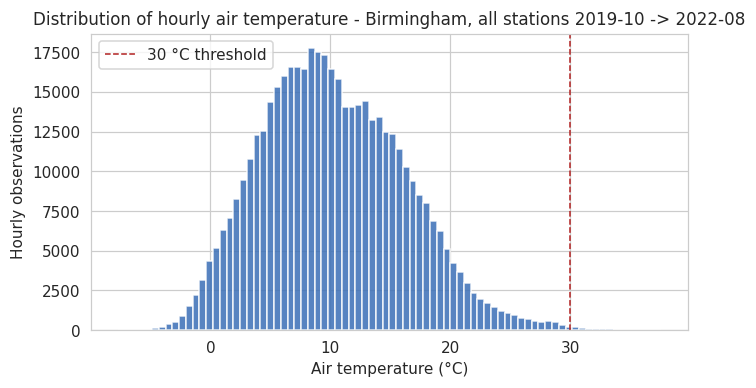

In [27]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(df['ta_C'].dropna(), bins=80, color='#3b6fb6', alpha=0.85, edgecolor='white')
ax.set_xlabel('Air temperature (°C)')
ax.set_ylabel('Hourly observations')
ax.set_title('Distribution of hourly air temperature - Birmingham, all stations 2019-10 -> 2022-08')
ax.axvline(30, color='firebrick', linestyle='--', linewidth=1, label='30 °C threshold')
ax.legend()
plt.show()

**Interpretation.** The distribution is roughly symmetric around 10 °C (Birmingham's oceanic mean) with a long but very thin right tail. Hours above 30 °C are genuinely rare — they account for well under 0.5 % of all observations across the dataset. This justifies the choice of 30 °C as a meaningful *extreme* threshold for this city: it captures genuine heat events rather than ordinary summer warmth.

### 6.2 Daily mean temperature time series

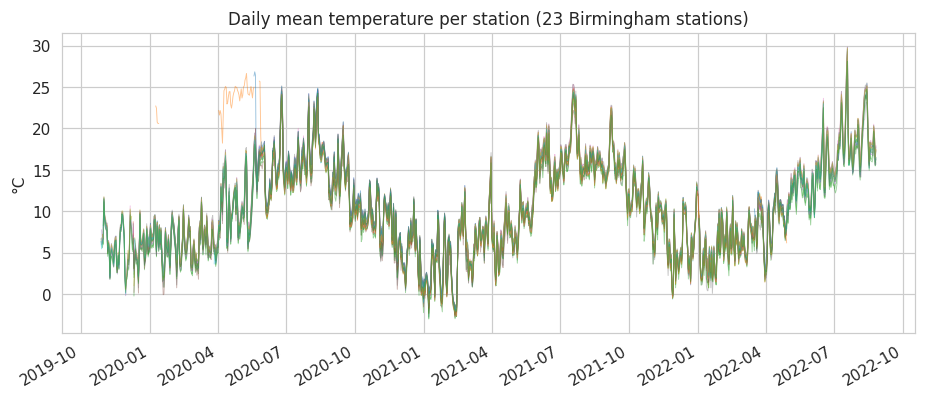

In [28]:
daily = df.groupby(['station_id', df['timestamp'].dt.date])['ta_C'].mean().reset_index()
daily.columns = ['station_id', 'date', 'ta_C']
daily['date'] = pd.to_datetime(daily['date'])

fig, ax = plt.subplots(figsize=(10, 4))
for st, sub in daily.groupby('station_id'):
    ax.plot(sub['date'], sub['ta_C'], lw=0.6, alpha=0.45)
ax.set_title('Daily mean temperature per station (23 Birmingham stations)')
ax.set_ylabel('°C')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.show()

**Interpretation.** The seasonal cycle dominates: Jan–Feb minima around 0–5 °C, Jul–Aug peaks of 18–22 °C (daily means; hourly peaks are higher). The July 2022 UK heatwave is clearly visible as the highest summer peak. Stations track each other closely on the seasonal axis but diverge in summer, which is the signal we care about.

### 6.3 Diurnal cycle in summer

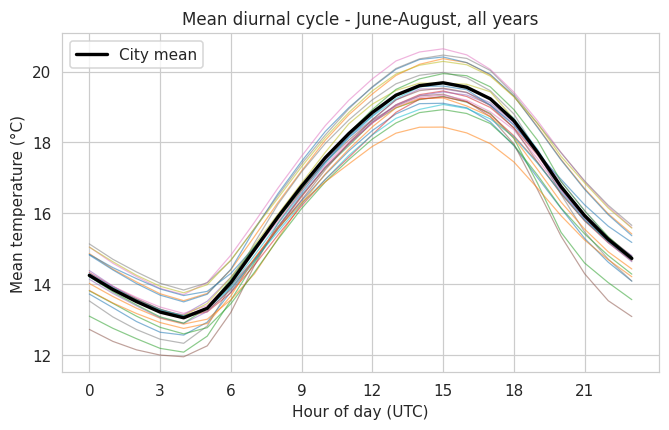

In [29]:
summer_mask = df['month'].isin([6, 7, 8])
diurnal = df.loc[summer_mask].groupby(['station_id', 'hour'])['ta_C'].mean().reset_index()

fig, ax = plt.subplots(figsize=(7, 4))
for st, sub in diurnal.groupby('station_id'):
    ax.plot(sub['hour'], sub['ta_C'], lw=0.8, alpha=0.55)
city_diurnal = df.loc[summer_mask].groupby('hour')['ta_C'].mean()
ax.plot(city_diurnal.index, city_diurnal.values, color='black', lw=2.2, label='City mean')
ax.set_xlabel('Hour of day (UTC)'); ax.set_ylabel('Mean temperature (°C)')
ax.set_title('Mean diurnal cycle - June-August, all years')
ax.set_xticks(range(0, 24, 3)); ax.legend(loc='upper left')
plt.show()

**Interpretation.** Summer afternoon peaks are reached at 13–15 UTC (≈14–16 BST). The peak-to-trough range is ≈8 °C across stations. Spread between stations is largest in the *afternoon*, exactly when heat-risk matters most, and smallest at night. This is encouraging: stations differ most when it counts. Note also that some stations stay warmer overnight than others (top of the band at 03 UTC), a candidate signal of urban heat-island effect, useful for Deliverable 3.

### 6.4 Monthly climatology

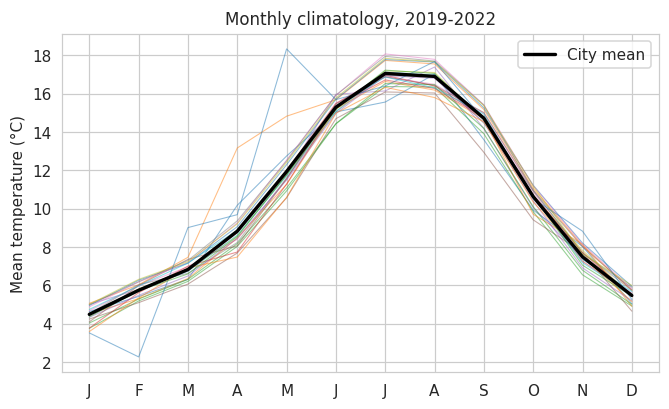

In [30]:
monthly = df.groupby(['station_id', 'month'])['ta_C'].mean().reset_index()
fig, ax = plt.subplots(figsize=(7, 4))
for st, sub in monthly.groupby('station_id'):
    ax.plot(sub['month'], sub['ta_C'], lw=0.7, alpha=0.5)
city_monthly = df.groupby('month')['ta_C'].mean()
ax.plot(city_monthly.index, city_monthly.values, color='black', lw=2.2, label='City mean')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax.set_ylabel('Mean temperature (°C)')
ax.set_title('Monthly climatology, 2019-2022')
ax.legend(); plt.show()

**Interpretation.** Standard mid-latitude oceanic seasonal cycle: minimum in January–February (~5 °C), maximum in July (~18 °C). Spring (Mar–May) and autumn (Sep–Nov) are nearly symmetric. The narrow spread *between* stations across the year, only ≈1 °C even in July, confirms Birmingham is climatologically homogeneous overall, which makes the *tail behaviour* (extreme hours) the right place to look for risk differences.

### 6.5 Mean temperature per station

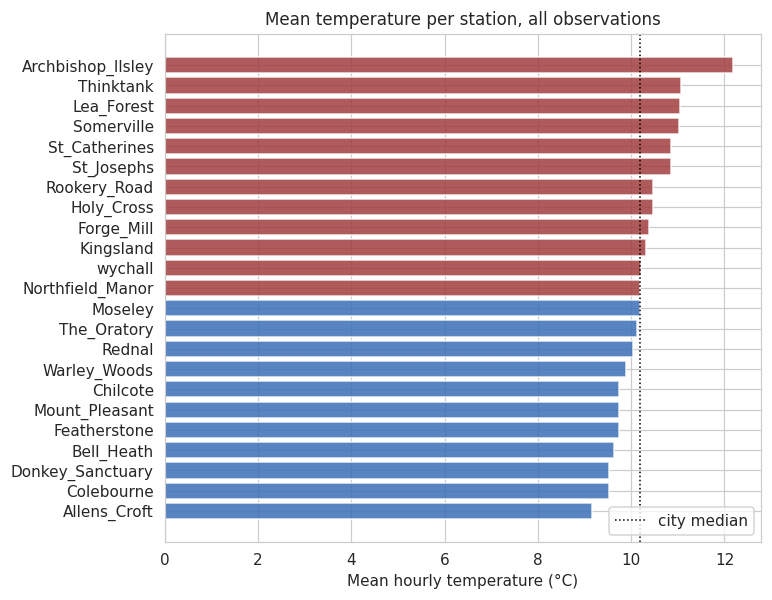

In [31]:
station_mean = df.groupby('station_id')['ta_C'].mean().sort_values()
colors = ['#a23e3e' if v >= station_mean.median() else '#3b6fb6' for v in station_mean]

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(station_mean.index, station_mean.values, color=colors, alpha=0.85)
ax.axvline(station_mean.median(), color='black', lw=1, linestyle=':', label='city median')
ax.set_xlabel('Mean hourly temperature (°C)')
ax.set_title('Mean temperature per station, all observations')
ax.legend(loc='lower right'); plt.show()

**Interpretation.** Station means are tightly packed around the city median the spread is only ≈1.5 °C top-to-bottom. *St_Catherines*, *Somerville*, and *Thinktank* sit at the warm end; *Donkey_Sanctuary*, *Bell_Heath*, *Rednal* at the cool end. Mean temperature alone is not the right metric for heat risk (a station can have a low mean but still spike high)  but the warm-cool ordering already foreshadows the ranking we will see in the exceedance metric.

### 6.6 Spatial distribution

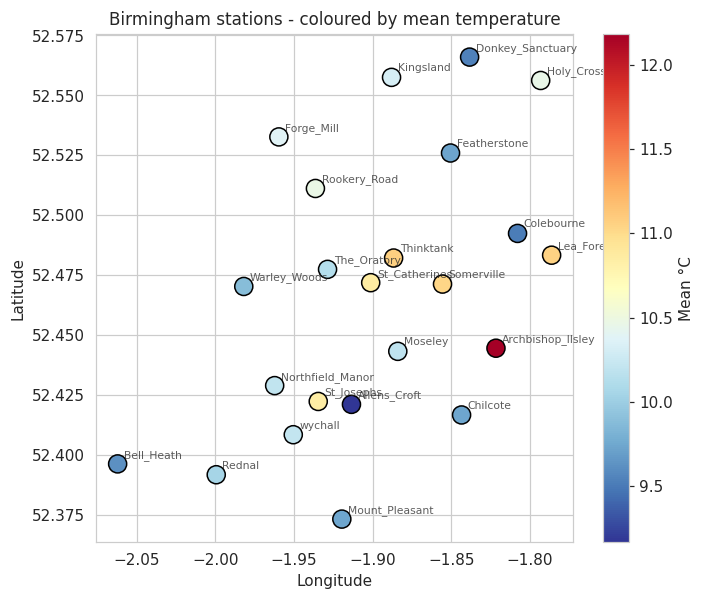

In [32]:
spatial = station_meta.merge(
    station_mean.rename('mean_ta_C').reset_index(), on='station_id')

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(spatial['longitude'], spatial['latitude'],
                c=spatial['mean_ta_C'], cmap='RdYlBu_r', s=140, edgecolor='black')
for _, row in spatial.iterrows():
    ax.annotate(row['station_id'], (row['longitude'], row['latitude']),
                fontsize=7, alpha=0.75, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Birmingham stations - coloured by mean temperature')
plt.colorbar(sc, ax=ax, label='Mean °C'); plt.show()

**Interpretation.** The warmest stations cluster in the *central and inner-east* parts of the network (*St_Catherines*, *Somerville*, *Archbishop_Ilsley*, *Thinktank*) broadly the urbanised core. The coolest sites (*Donkey_Sanctuary*, *Bell_Heath*, *Rednal*) are at the periphery, consistent with rural / green-edge locations. This urban-vs-edge gradient is the qualitative signature of the urban heat island and is the spatial pattern the Deliverable 3 narrative will hinge on.

## 8. Conclusions and plan for Deliverable 2

### 8.1 What we found in Deliverable 1

1. The Birmingham subset of FAIRUrbTemp contains 23 street-level stations, 570,515 hourly rows, covering 2019-10 to 2022-08. The hourly grid is complete and there are no duplicates.
2. Two material data-quality issues were observed and addressed:
    - **584 sentinel values** clustering around −150 °C (peak −488 °C) that were not flagged by the data provider's QC. We applied a physical-plausibility filter at −25 / +50 °C.
    - **Heterogeneous missingness** ranging from 0.2 % to 70 %. We carry a *summer-completeness* flag through the analysis so sparse-coverage stations can be visually distinguished and treated with appropriate uncertainty.
3. The diurnal and seasonal cycles are well behaved and consistent with Birmingham's oceanic climate.
4. An **initial heat-risk ranking** based on exceedance above 30 °C in summer cleanly separates a high-exposure cluster from a low-exposure cluster.
5. The exceedance ranking is internally consistent (Spearman ρ = 0.97 vs. P95) and not obviously biased by missingness, a defensible baseline screening output.

### 8.3 Plan for Deliverable 2

Reuse the same loader and quality pipeline on Berlin and Basel, build a small set of complementary metrics, run the threshold / filtering / temporal sensitivity analyses, and report stability via Spearman rank correlations of the top-k between conditions. The Deliverable 1 codebase here is structured so that switching cities is a one-line change to `HOURLY_DIR` / `META_DIR`.